In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Can the grader understand the answer without changing the task?

Chapter 7 · Day 10 · Offline instrument laboratory

A half can appear as `0.5`, `1/2` or a nested boxed fraction. Should they receive the same answer score? What if the task required one integer, two different answers are boxed, a unit is missing, or generation stopped at its cap?

Separate extraction, supported equivalence, required format and termination. Then replay every raw response from an original frozen regression panel. The checkpoint labels below identify **authored fixtures**, not trained models. All costs and token IDs are explicitly unknown; no model, API, network or GPU is used.

In [2]:
from pathlib import Path
import sys, json
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/dongxi_llms').is_dir())
sys.path.insert(0, str(root / 'src'))
import numpy as np
import matplotlib.pyplot as plt
from dongxi_llms import reasoning_evaluation as ev
plt.rcParams.update({'figure.facecolor':'white', 'axes.facecolor':'white',
                     'font.family':'DejaVu Sans', 'font.size':10})
folder = root / 'fixtures/reasoning-evaluation'
items = json.loads((folder / 'items.json').read_text())
settings = json.loads((folder / 'settings.json').read_text())
records = [json.loads(line) for line in (folder / 'responses.jsonl').read_text().splitlines() if line.strip()]
contract = ev.freeze_contract(items, settings)
assert all(record['contract_id'] == contract['identity'] for record in records)
contract

{'schema_version': 'dongxi-response-record-v1',
 'parser_version': 'bounded-rational-set-interval-v1',
 'rubric_version': 'explicit-marker-fixture-v1',
 'suite_sha256': '99ee3b459f4339140e1b8297a28f8a37b62321bff471d71e6975e4a820e2cb82',
 'settings': {'template_id': 'authored-raw-fixture-v1',
  'thinking_mode': 'not-applicable-authored-records',
  'decoding': {'mode': 'not-generated', 'seed': None},
  'stopping': {'natural': 'eos', 'cap': 'max_tokens', 'failure': 'error'},
  'max_new_tokens': 64},
 'identity': 'a4b305398408b67b12547fa9b644ab4016f6d93294fb6021086e4729198d71fa'}

## Predict 1

Does choosing the last number from an explanation solve answer extraction? Could that award credit when the response presents two mutually incompatible answers?

Predict before revealing the contract. You can change one local `records` dictionary later; keep the original fixture files frozen.

### Reference answer and mechanism

No. Last-number rescue hides ambiguity and can reward a wrong explanation. This instrument accepts one balanced box, one explicit `Final answer:` line, or the entire response. Multiple explicit answer markers stay `AMBIGUOUS`, even if they agree. Fractions inside a box require balanced nested braces.

The diagram is a **schematic scoring pipeline**, not a model architecture or measured performance trace.

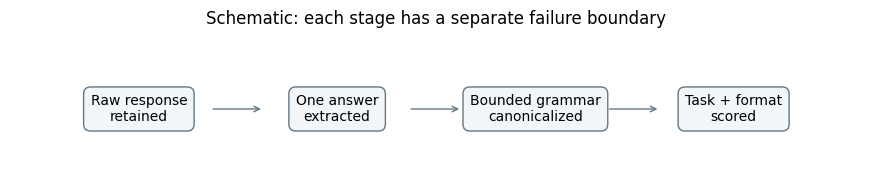

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.0))
labels = ['Raw response\nretained', 'One answer\nextracted', 'Bounded grammar\ncanonicalized', 'Task + format\nscored']
for i, label in enumerate(labels):
    ax.text(i, .5, label, ha='center', va='center', bbox=dict(boxstyle='round,pad=.5', fc='#f3f6f8', ec='#637785'))
    if i: ax.annotate('', (i-.37,.5), (i-.64,.5), arrowprops=dict(arrowstyle='->', color='#637785'))
ax.set(xlim=(-.65,3.65), ylim=(0,1), title='Schematic: each stage has a separate failure boundary')
ax.axis('off'); plt.show()
assert ev.extract_answer(r'\boxed{1} and \boxed{2}')['status'] == 'AMBIGUOUS'
assert ev.extract_answer(r'\boxed{\frac{3}{\frac{6}{2}}}')['mechanism'] == 'boxed'

**Saved reference preview — rerun the preceding cell for current inputs.**

![Schematic separates raw answer retention, extraction, supported canonicalization and task scoring](../figures/chapter-07/day-10-04_mathematical_grading_and_response_replay-01.png)

This image is a fixed CPU reference, not model-generated evidence. Changing a response does not automatically update the preview.

## Predict 2

Will `0.3333333333333333` equal `1/3` exactly? Will `100 cm` equal `1 m`? Does the closing bracket in `[1,2)` matter?

### Reference answer and mechanism

Not under this contract. Decimal literals become exact rational numbers, so a rounded third is not exactly one third. Named unit aliases match (`seconds` and `s`), but unit conversion is not implemented. Interval endpoints and whether they are included remain part of the answer.

Finite sets ignore order and duplicates. Variables, square roots and arbitrary code are `UNSUPPORTED`, not silently wrong symbolic simplifications. Malformed arithmetic or a zero denominator is `INVALID`. A resource bound rejects excessive size/depth. Unsupported grammar is a limitation of the grader; preserve it separately from an ordinary wrong answer.

fraction-decimal              CORRECT
exact-not-rounded             INCORRECT
rational-expression           CORRECT
nested-fraction               CORRECT
negative-fraction             CORRECT
unordered-set                 CORRECT
empty-set                     CORRECT
interval-closure              INCORRECT
interval-infinity             CORRECT
invalid-infinity              INVALID
reversed-interval             INVALID
matching-unit                 CORRECT
unit-mismatch                 INCORRECT
unit-missing                  INCORRECT
no-unit-conversion            INCORRECT
unknown-unit                  UNSUPPORTED
zero-denominator              INVALID
root-not-in-grammar           UNSUPPORTED
variable-not-in-grammar       UNSUPPORTED
python-injection              UNSUPPORTED
huge-power                    INVALID
ambiguous-numeric-prose       UNSUPPORTED
numeric-digit-bound           INVALID


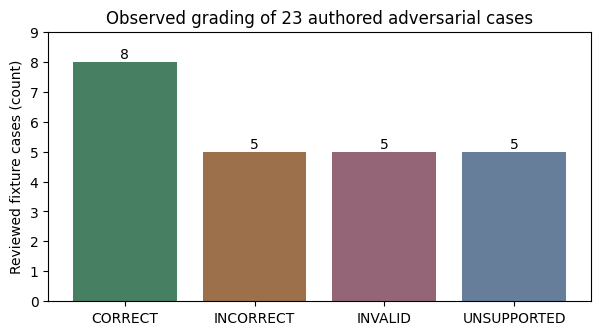

In [4]:
cases = json.loads((folder / 'grading_cases.json').read_text())
observed = []
for case in cases:
    parsed = ev.canonicalize_answer(case['input'])
    expected = ev.canonicalize_answer(case['reference'])
    status = parsed['status']
    if status == 'SUPPORTED':
        status = 'CORRECT' if parsed['canonical'] == expected['canonical'] else 'INCORRECT'
    assert status == case['status'], case['id']
    observed.append((case['id'], status))
for name, status in observed: print(f'{name:29} {status}')
statuses = ['CORRECT','INCORRECT','INVALID','UNSUPPORTED']
counts = [sum(status == label for _,status in observed) for label in statuses]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(statuses, counts, color=['#477f62','#9b704b','#946577','#667e99'])
ax.set(ylabel='Reviewed fixture cases (count)', title='Observed grading of 23 authored adversarial cases')
for i,count in enumerate(counts): ax.text(i,count+.12,str(count),ha='center')
ax.set_ylim(0,max(counts)+1); plt.show()

**Saved reference preview — rerun the preceding cell for current inputs.**

![Counts of supported correct, supported incorrect, invalid and unsupported authored grading cases](../figures/chapter-07/day-10-04_mathematical_grading_and_response_replay-02.png)

This image is a fixed CPU reference, not model-generated evidence. Changing a response does not automatically update the preview.

## Predict 3

The candidate panel has a higher aggregate task score. Must JSON validity and set membership improve? If an answer is correct but truncated, should we relabel its stop as natural?

### Reference answer and mechanism

No to both. A panel can improve common items while regressing on a rare task. Correctness, required format and natural stopping are distinct observations. The authored `stopping-a` response has correct text but a deliberately simulated max-token stop. Its correctness does not prove EOS termination.

`task_success` here means correctness AND required format. Natural termination is reported separately. Errors, ambiguous outputs and unsupported grammar remain in the all-record denominator. If your task requires natural termination for success, create a named metric/contract instead of silently changing this definition.

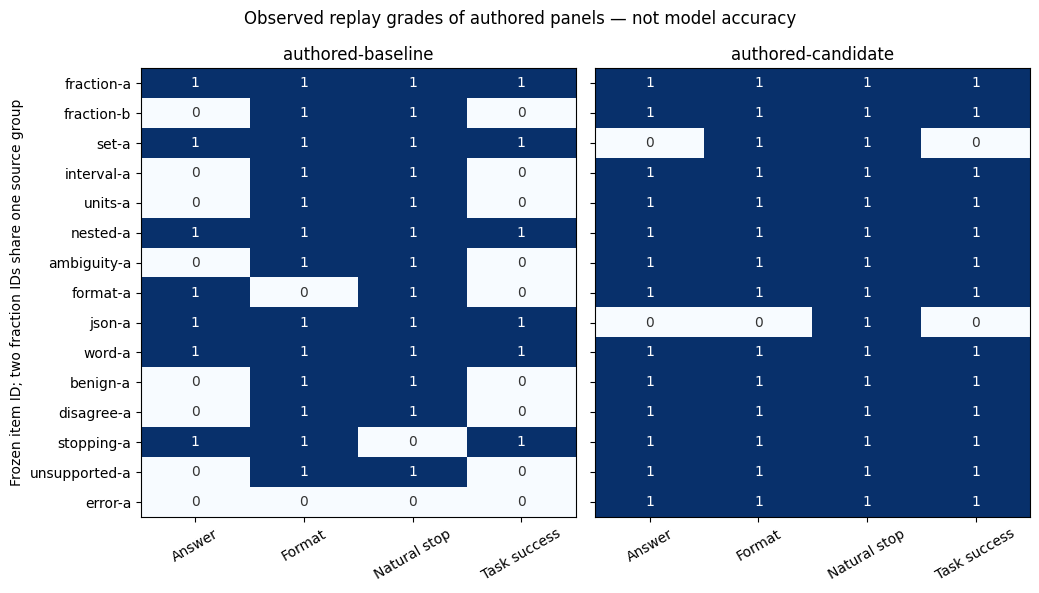

authored-baseline {'n': 15, 'accuracy': 0.4666666666666667, 'task_success': 0.4, 'format_valid': 0.8666666666666667, 'natural_termination': 0.8666666666666667, 'truncation': 0.06666666666666667, 'stop_reasons': {'eos': 13, 'max_tokens': 1, 'error': 1}, 'statuses': {'CORRECT': 7, 'INCORRECT': 5, 'AMBIGUOUS': 1, 'UNSUPPORTED': 1, 'ERROR': 1}, 'cost': {'wall_seconds': {'known_total': 0, 'unknown_rows': 15}, 'generation_tokens': {'known_total': 0, 'unknown_rows': 15}, 'scoring_tokens': {'known_total': 0, 'unknown_rows': 15}}}
authored-candidate {'n': 15, 'accuracy': 0.8666666666666667, 'task_success': 0.8666666666666667, 'format_valid': 0.9333333333333333, 'natural_termination': 1.0, 'truncation': 0.0, 'stop_reasons': {'eos': 15}, 'statuses': {'CORRECT': 13, 'INCORRECT': 1, 'INVALID': 1}, 'cost': {'wall_seconds': {'known_total': 0, 'unknown_rows': 15}, 'generation_tokens': {'known_total': 0, 'unknown_rows': 15}, 'scoring_tokens': {'known_total': 0, 'unknown_rows': 15}}}


In [5]:
report = ev.replay_records(items, records, contract)
keys = ['authored-baseline','authored-candidate']
by_model = {key: {row['item_id']:row for row in report['rows'] if row['checkpoint_id']==key} for key in keys}
metrics = ['correct','format_valid','natural_termination','task_success']
fig, axes = plt.subplots(1,2,figsize=(10.5,6.0),sharey=True)
for ax,key in zip(axes,keys):
    matrix = np.array([[by_model[key][item['id']].get(metric,False) for metric in metrics] for item in items],dtype=int)
    ax.imshow(matrix, vmin=0, vmax=1, cmap='Blues', aspect='auto')
    ax.set(xticks=range(4), xticklabels=['Answer','Format','Natural stop','Task success'],
           yticks=range(len(items)), yticklabels=[item['id'] for item in items], title=key)
    ax.tick_params(axis='x',rotation=30)
    for i in range(len(items)):
        for j in range(4): ax.text(j,i,str(matrix[i,j]),ha='center',va='center',color='white' if matrix[i,j] else '#333')
axes[0].set_ylabel('Frozen item ID; two fraction IDs share one source group')
fig.suptitle('Observed replay grades of authored panels — not model accuracy')
fig.tight_layout(); plt.show()
for key in keys:
    print(key, report['checkpoints'][key]['summary'])
assert report['checkpoints'][keys[1]]['slices']['task']['sets']['accuracy'] == 0
assert report['checkpoints'][keys[1]]['slices']['task']['json-format']['format_valid'] == 0

**Saved reference preview — rerun the preceding cell for current inputs.**

![Per-item answer, format, natural termination and task success for two authored response panels](../figures/chapter-07/day-10-04_mathematical_grading_and_response_replay-03.png)

This image is a fixed CPU reference, not model-generated evidence. Changing a response does not automatically update the preview.

## Predict 4

The two fraction prompts share a source template. Should their paired score differences be resampled independently? Can unknown generation costs be replaced by the number of characters in the string?

### Reference answer and mechanism

Resample the complete source group, so its sibling items travel together. The estimand remains the micro-average difference B minus A; cluster sizes stay unequal. A percentile interval from fourteen authored groups does not establish a population capability gain, regardless of its sign.

Unknown token counts and cost boundaries remain `null`. Characters are not tokens, replay time is not generation time, and a fabricated zero would falsely suggest a free inference system. The summary reports known totals alongside the number of unknown records.

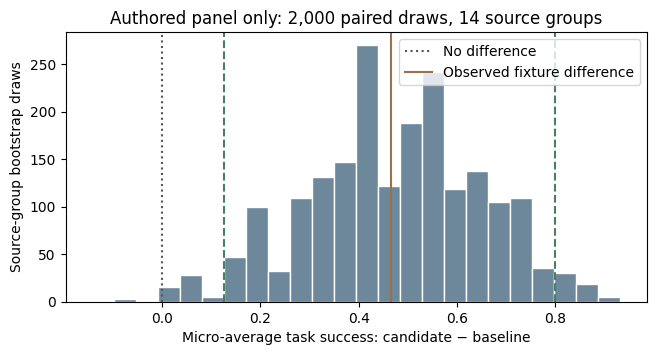

{'metric': 'task_success', 'delta': 0.4666666666666667, 'interval': [0.125, 0.8], 'n_items_samples': 15, 'n_source_groups': 14, 'unit': 'source_group', 'draws': 2000, 'seed': 1010, 'limits': 'Percentile cluster bootstrap; a small authored panel is not a generalization benchmark.'}


In [6]:
a = [row for row in report['rows'] if row['checkpoint_id']==keys[0]]
b = [row for row in report['rows'] if row['checkpoint_id']==keys[1]]
comparison = ev.paired_group_bootstrap(a,b,draws=2000,seed=1010)
fig, ax = plt.subplots(figsize=(7.5,3.5))
ax.hist(comparison['samples'], bins=24, color='#6d879b', edgecolor='white')
ax.axvline(0,color='#555',linestyle=':',label='No difference')
ax.axvline(comparison['delta'],color='#9b704b',label='Observed fixture difference')
for bound in comparison['interval']: ax.axvline(bound,color='#477f62',linestyle='--')
ax.set(xlabel='Micro-average task success: candidate − baseline', ylabel='Source-group bootstrap draws',
       title='Authored panel only: 2,000 paired draws, 14 source groups')
ax.legend(); plt.show()
print({key:value for key,value in comparison.items() if key!='samples'})
assert comparison['n_source_groups']==14
assert report['checkpoints'][keys[0]]['summary']['cost']['generation_tokens']['unknown_rows']==15

**Saved reference preview — rerun the preceding cell for current inputs.**

![Source-group bootstrap distribution for the authored fixture micro-average difference](../figures/chapter-07/day-10-04_mathematical_grading_and_response_replay-04.png)

This image is a fixed CPU reference, not model-generated evidence. Changing a response does not automatically update the preview.

## Controlled perturbation and runnable solution

Replace only the candidate's `format-a` response by `Final answer: 4`, replay, and inspect answer versus format score. Then try comparing panels after deleting one response: an unmatched pair must fail rather than compare different populations.

In [7]:
import copy
changed = copy.deepcopy(records)
row = next(row for row in changed if row['checkpoint_id']==keys[1] and row['item_id']=='format-a')
row['raw_response'] = 'Final answer: 4'
perturbed = ev.replay_records(items,changed,contract)
check = next(row for row in perturbed['rows'] if row['checkpoint_id']==keys[1] and row['item_id']=='format-a')
assert check['correct'] and not check['format_valid'] and not check['task_success']
try:
    ev.paired_group_bootstrap(a,b[:-1])
except ValueError as error:
    print('Expected population mismatch:',error)
else:
    raise AssertionError('Unmatched comparison was silently accepted')
view = ev.candidate_view(dict(b[0],reference='DO NOT EXPOSE',oracle_correct=True))
assert 'reference' not in view and 'correct' not in view and 'oracle_correct' not in view

Expected population mismatch: Paired comparison requires identical item/sample coverage


## Interpretation and next evidence

We have checked exact grammar, extraction boundaries, fixture regressions, stopping/error retention and paired source-group accounting. We have not evaluated Qwen or measured inference cost. The marker-based benign-refusal/disagreement rubrics only distinguish the authored positive and negative cases; they cannot certify broad safety, helpfulness or truthfulness.

Before applying this to real checkpoints, build the separately invoked generation adapter, freeze model/tokenizer/template/thinking identities, collect every completion/token/stop/cost record and independently review the task/rubric population. Keep gold references out of candidate selection. The existing integer-only RLVR verifier remains a different, unchanged task.

Read [Chapter 7](../../book/chapters/07-evaluation-is-a-contract.md), [worked solutions](../../book/solutions/07-evaluation-is-a-contract.md), [fixture review](../../fixtures/reasoning-evaluation/README.md) and [bounded report](../../experiments/reports/2026-10-04-reasoning-evaluation.md).